# 09 Práctica de laboratorio: Aprendizaje no supervisado, clustering y PCA

**Aprendizaje Computacional I**

**Nombre y apellidos:** Miguel Adrian Gheorghe

# Introducción

En esta práctica trabajaremos con técnicas de **aprendizaje no supervisado**.

A diferencia del aprendizaje supervisado, en el aprendizaje no supervisado no usamos las etiquetas para entrenar el modelo.
El objetivo no es predecir una clase conocida, sino descubrir estructura en los datos.

Estudiaremos:

- clustering con k-medias,
- elección del número de clusters,
- silhouette score,
- DBSCAN,
- detección de ruido,
- PCA,
- visualización en dos dimensiones,
- y comparación posterior con etiquetas ocultas.

La comparación con etiquetas reales se hará solo al final y con fines de análisis.
Durante el entrenamiento de los modelos no supervisados no se deben usar esas etiquetas.

# Objetivos

Al finalizar esta práctica deberías ser capaz de:

- cargar y explorar un dataset real,
- aplicar escalado antes de clustering y PCA,
- entrenar modelos k-medias,
- analizar la inercia y el silhouette score,
- interpretar clusters sin usar etiquetas,
- aplicar DBSCAN,
- interpretar puntos marcados como ruido,
- aplicar PCA para reducir dimensionalidad,
- visualizar datos en dos componentes principales,
- comparar clusters con etiquetas ocultas usando métricas externas,
- razonar las diferencias entre aprendizaje supervisado y no supervisado.

# Dataset: Wine

Trabajaremos con el dataset **Wine**, incluido en `scikit-learn`.

Este dataset contiene medidas químicas de vinos procedentes de tres variedades diferentes.

Las variables son numéricas e incluyen, entre otras:

- alcohol,
- ácido málico,
- cenizas,
- alcalinidad,
- magnesio,
- fenoles,
- flavonoides,
- intensidad de color,
- tono,
- prolina.

El dataset incluye etiquetas reales de clase, pero en esta práctica las trataremos como **etiquetas ocultas**.

Es decir:

- no se usarán para entrenar k-medias, DBSCAN ni PCA,
- solo se usarán al final para comparar si los grupos descubiertos se parecen a las clases reales.

# Librerías necesarias

Ejecuta la siguiente celda.

In [1]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import load_wine

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# PCA
from sklearn.decomposition import PCA

# Métricas de clustering
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix
)

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (8, 6)

# Código de estudiante

## Ejercicio 1

Introduce tu código de estudiante.

Este código se usará como semilla aleatoria en k-medias y en algunas visualizaciones.

In [2]:
CODIGO_ESTUDIANTE = 40

np.random.seed(CODIGO_ESTUDIANTE)

# Carga del dataset

## Ejercicio 2

Carga el dataset Wine usando `load_wine`.

Crea:

- una matriz de variables predictoras `X`,
- un vector de etiquetas reales `y_oculta`,
- un `DataFrame` llamado `datos` con las variables predictoras.

Recuerda: `y_oculta` no debe usarse para entrenar los modelos no supervisados.

In [3]:
# COMPLETAR
X, y_oculta = load_wine(return_X_y=True, as_frame=True)

## Ejercicio 3

Muestra:

- las primeras filas del dataset,
- el número de ejemplos,
- el número de variables,
- los nombres de las variables.

In [4]:
# COMPLETAR
print(f"Primeras filas:")
display(X.head())
print(f"Número de ejemplos: {X.shape[0]}")
print(f"Número de variables: {X.shape[1]}")
print(f"Nombre de variables: {X.columns}")

Primeras filas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Número de ejemplos: 178
Número de variables: 13
Nombre de variables: Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='str')


# Exploración inicial

## Ejercicio 4

Calcula estadísticos descriptivos de las variables:

- media,
- desviación típica,
- mínimo,
- máximo.

Pregunta:

- ¿Tienen todas las variables escalas parecidas?

In [5]:
# COMPLETAR
X.describe().loc[["mean", "std", "min", "max"]]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


**Respuesta.**

No, las variables tienen escalas diferentes. Hay variables que su máximo es 0.66 y otras que su máximo es 1680.

## Ejercicio 5

Representa histogramas de algunas variables.

Elige al menos cuatro variables químicas.

Pregunta:

- ¿Observas variables con distribuciones muy diferentes?

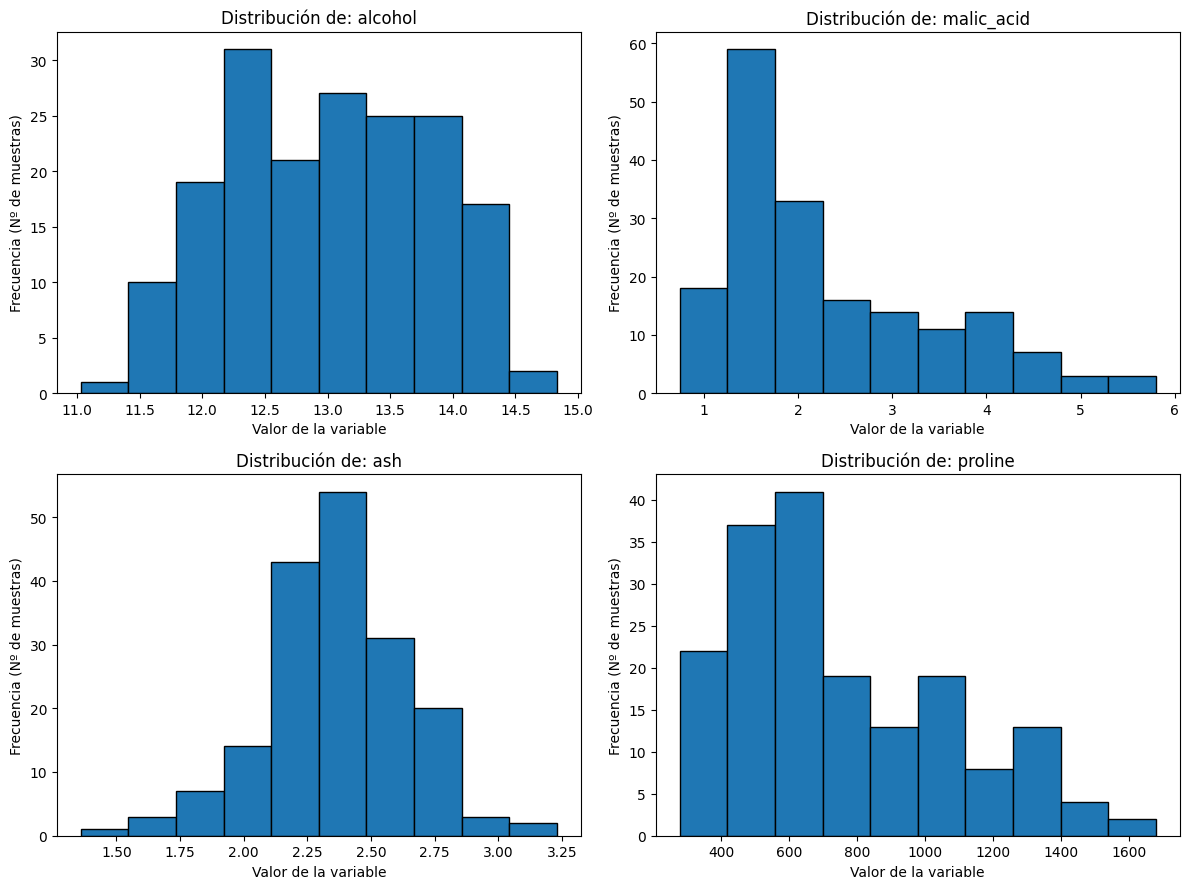

In [6]:
# COMPLETAR
variables_quimicas = ["alcohol", "malic_acid", "ash", "proline"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for i, col in enumerate(variables_quimicas):
    axes[i].hist(X[col], edgecolor="black")
    axes[i].set_title(f"Distribución de: {col}", fontsize=12)
    axes[i].set_xlabel("Valor de la variable")
    axes[i].set_ylabel("Frecuencia (Nº de muestras)")

plt.tight_layout()
plt.show()

**Respuesta.**

Si, las variables tienen distribuciones diferentes. Algunas como ash con una distribución normal o la de malic acid que tiene asimetría positiva.

# Escalado de variables

## Ejercicio 6

Escala las variables usando `StandardScaler`.

Crea una matriz llamada `X_scaled`.

Pregunta:

- ¿Por qué es necesario escalar antes de aplicar k-medias, DBSCAN o PCA?

In [7]:
# COMPLETAR
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

**Respuesta.**

Porque estos algoritmos dependen de calcular distancias o buscar la máxima varianza, las variables con números más grandes dominan el cálculo y anulan a las pequeñas. Escalar sitúa a todas en la misma escala para que pesen lo mismo.

# k-medias con un número fijo de clusters

## Ejercicio 7

Entrena un modelo k-medias con:

- `n_clusters = 3`,
- `random_state = CODIGO_ESTUDIANTE`,
- `n_init = 10`.

Guarda las etiquetas de cluster en una variable llamada `clusters_k3`.

In [8]:
# COMPLETAR
km1 = KMeans(n_clusters=3, random_state=CODIGO_ESTUDIANTE, n_init=10)
clusters_k3 = km1.fit_predict(X_scaled)

## Ejercicio 8

Cuenta cuántos ejemplos han quedado asignados a cada cluster.

Pregunta:

- ¿Tienen todos los clusters un tamaño parecido?

In [9]:
# COMPLETAR
cont_clusters = pd.Series(clusters_k3).value_counts().sort_index()

for cluster, total in cont_clusters.items():
    print(f"Cluster {cluster}: {total} vinos")

Cluster 0: 62 vinos
Cluster 1: 51 vinos
Cluster 2: 65 vinos


**Respuesta.**

Sí, y no sufren de un desbalanceo extremo.

# Elección del número de clusters: método del codo

## Ejercicio 9

Entrena modelos k-medias para:

$$
k \in \{2,3,4,5,6,7,8,9,10\}
$$

Guarda la inercia de cada modelo.

In [10]:
# COMPLETAR
k_vals = range(2, 11)
inercias = []

for k in k_vals:
    km = KMeans(n_clusters=k, random_state=CODIGO_ESTUDIANTE, n_init=10)
    km.fit(X_scaled)
    inercias.append({
        "k" : k,
        "inercia": km.inertia_
    })

inercias = pd.DataFrame(inercias)

## Ejercicio 10

Representa la inercia frente a `k`.

Pregunta:

- ¿Dónde parece estar el codo?

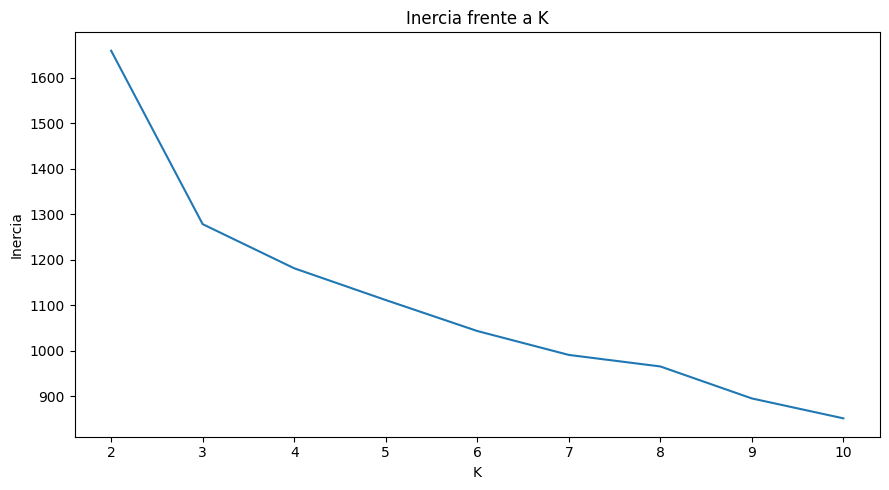

In [11]:
# COMPLETAR
plt.figure(figsize=(9, 5))
plt.plot(k_vals, inercias["inercia"])
plt.title("Inercia frente a K")
plt.xlabel("K")
plt.ylabel("Inercia")
plt.xticks(k_vals, labels=[str(c) for c in k_vals]) 
plt.tight_layout()
plt.show()

**Respuesta.**

Vemos un claro punto de inflexión en K = 3, donde la inercia sigue decreciendo pero de forma más suave a diferencia de al principio. Por el criterio del codo, el codo se encuentra en K = 3.

# Elección del número de clusters: silhouette score

## Ejercicio 11

Calcula el **silhouette score** para:

$$
k \in \{2,3,4,5,6,7,8,9,10\}
$$

Recuerda que el silhouette score solo está definido cuando hay al menos dos clusters.

In [12]:
# COMPLETAR
silhouettes = []

for k in k_vals:
    km = KMeans(n_clusters=k, random_state=CODIGO_ESTUDIANTE, n_init=10)
    etiquetas = km.fit_predict(X_scaled)
    silhouettes.append({
        "k" : k,
        "silhouette": silhouette_score(X_scaled, etiquetas)
    })

silhouettes = pd.DataFrame(silhouettes)

## Ejercicio 12

Representa el silhouette score frente a `k`.

Pregunta:

1. ¿Qué valor de `k` obtiene mayor silhouette score?
2. ¿Coincide con lo observado con el método del codo?

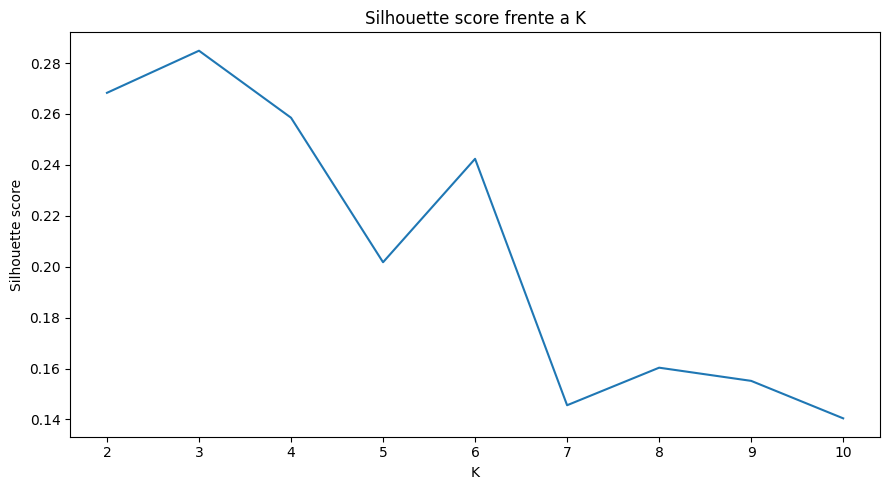

In [13]:
# COMPLETAR
plt.figure(figsize=(9, 5))
plt.plot(k_vals, silhouettes["silhouette"])
plt.title("Silhouette score frente a K")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.xticks(k_vals, labels=[str(c) for c in k_vals]) 
plt.tight_layout()
plt.show()

**Respuesta.**

Con el valor de K = 3 obtenemos el score máximo score, coincidiendo con lo que dijimos del criterio del codo.

# PCA para visualización

## Ejercicio 13

Aplica PCA a los datos escalados usando dos componentes principales.

Crea:

- `pca`,
- `X_pca`.

In [14]:
# COMPLETAR
pca = PCA(n_components=2, random_state=CODIGO_ESTUDIANTE)
X_pca = pca.fit_transform(X_scaled)

## Ejercicio 14

Muestra la varianza explicada por las dos primeras componentes principales.

Pregunta:

- ¿Qué porcentaje de la varianza total explican conjuntamente PC1 y PC2?

In [15]:
# COMPLETAR
varianza_explicada = pca.explained_variance_ratio_
print(f"PC1 explica {varianza_explicada[0] * 100}%")
print(f"PC2 explica {varianza_explicada[1] * 100}%")
print(f"Varianza total {varianza_explicada.sum() * 100}")

PC1 explica 36.198848099926316%
PC2 explica 19.20749025700894%
Varianza total 55.40633835693526


**Respuesta.**
PC1 y PC2 explican alrededor del 55.4% de la varianza total del dataset.


## Ejercicio 15

Representa los datos proyectados sobre PC1 y PC2, coloreando los puntos según los clusters obtenidos con k-medias para `k=3`.

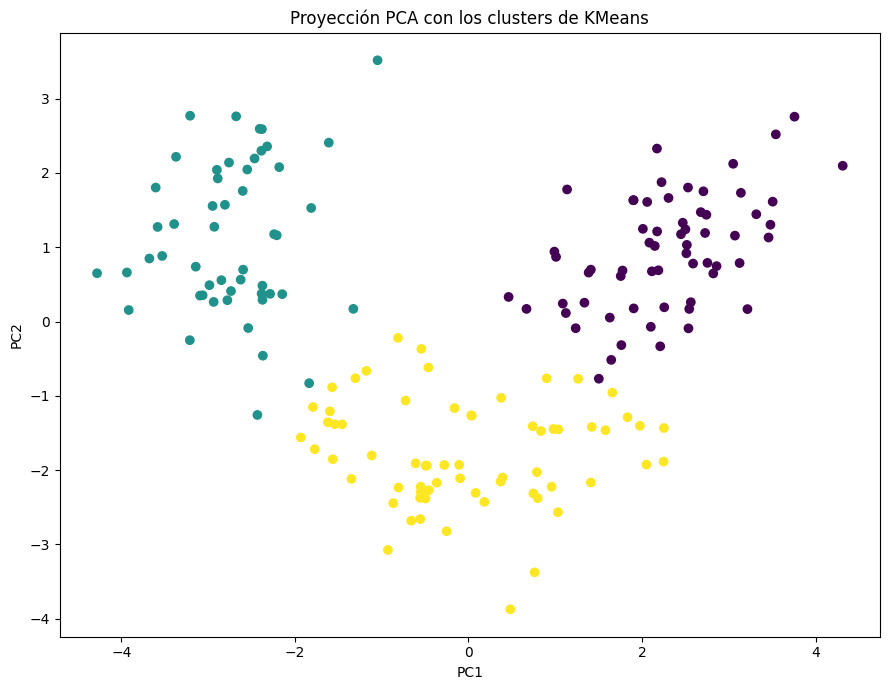

In [16]:
# COMPLETAR
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

plt.figure(figsize=(9, 7))
plt.scatter(pc1, pc2, c=clusters_k3)
plt.title("Proyección PCA con los clusters de KMeans")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Ejercicio 16

Pregunta:

1. ¿Los clusters parecen separados en el plano PCA?
2. ¿Hay solapamientos?
3. ¿Qué limitación tiene visualizar solo dos componentes principales?

**Respuesta.**

1. Si, muestran una separación clara en tres regiones claramente distinguidas.
2. La separación es casi perfecta pero hay un poco de contacto en las fronteras.
3. Que hemos perdido un 44% de la información original.

# Comparación con etiquetas ocultas

Hasta ahora no hemos usado las etiquetas reales de los vinos.
Ahora las usaremos solo para analizar si los grupos descubiertos por k-medias se parecen a las clases reales.

Esto no convierte el método en supervisado, porque las etiquetas no se han usado para entrenar.

## Ejercicio 17

Representa los datos proyectados sobre PC1 y PC2, coloreando ahora según las etiquetas reales `y_oculta`.

Compara visualmente esta figura con la figura coloreada por k-medias.

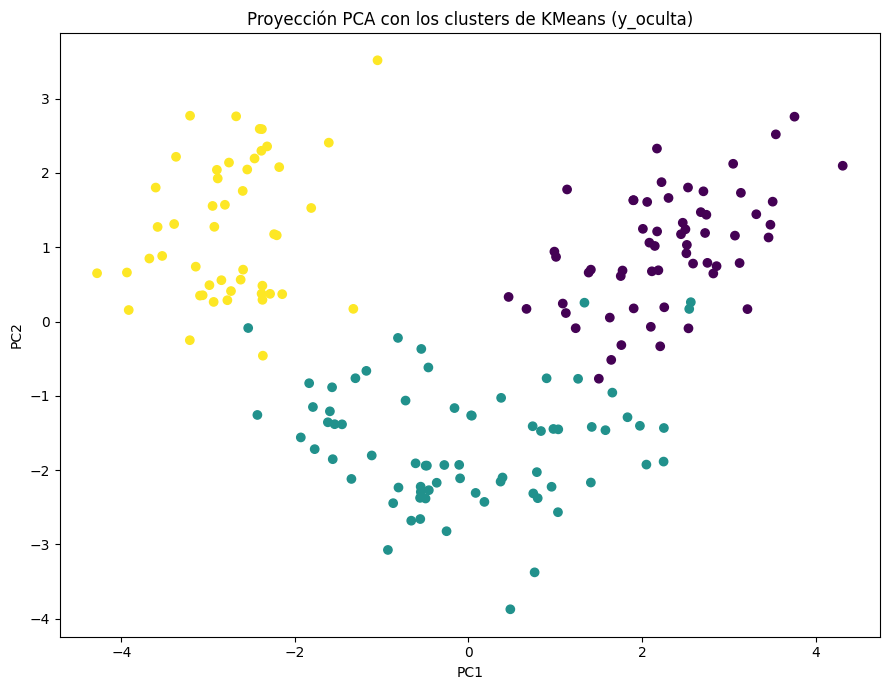

In [17]:
# COMPLETAR
plt.figure(figsize=(9, 7))
plt.scatter(pc1, pc2, c=y_oculta)
plt.title("Proyección PCA con los clusters de KMeans (y_oculta)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Ejercicio 18

Calcula dos métricas externas de comparación entre los clusters de k-medias y las etiquetas ocultas:

- Adjusted Rand Index,
- Normalized Mutual Information.

In [18]:
# COMPLETAR
ari = adjusted_rand_score(y_oculta, clusters_k3)
nmi = normalized_mutual_info_score(y_oculta, clusters_k3)

print(f"ARI: {ari * 100}")
print(f"NMI: {nmi * 100}")

ARI: 89.74949815093207
NMI: 87.58935341223068


## Ejercicio 19

Pregunta:

1. ¿Los clusters de k-medias coinciden perfectamente con las clases reales?
2. ¿Qué indican ARI y NMI?
3. ¿Por qué puede haber diferencias entre clusters y clases reales?

**Respuesta.**

1. Casi a la perfección, excepto algunos puntos que cruzan alguna frontera.
2. ARI: mide la similitud entre las dos clasificaciones evaluando cuántas parejas de puntos se agruparon de forma correcta o incorrecta (0 es aleatorio). Obtenemos un 90%.
   NMI: mide cuánta información compartida ganamos sobre las etiquetas reales si conocemos los clusters. Obtenemos un 88%
3. Por el ruido de las muestras, el solapamiento en las fronteras y porque K-medias asume que todos los grupos son esféricos.

# DBSCAN

## Ejercicio 20

Entrena un modelo DBSCAN sobre los datos escalados.

Empieza con:

- `eps = 1.5`,
- `min_samples = 5`.

Guarda las etiquetas en `clusters_dbscan`.

In [19]:
# COMPLETAR
dbs1 = DBSCAN(eps=1.5, min_samples=5)
clusters_dbs = dbs1.fit_predict(X_scaled)

## Ejercicio 21

Cuenta:

- cuántos clusters detecta DBSCAN,
- cuántos puntos marca como ruido.

Recuerda que DBSCAN etiqueta el ruido como `-1`.

In [20]:
# COMPLETAR
cont_dbs = pd.Series(clusters_dbs).value_counts().sort_index()

for cluster, total in cont_dbs.items():
    if cluster == -1:
        print(f"Puntos como ruido {total}")
    else:
        print(f"Cluster {cluster}: {total} vinos")

Puntos como ruido 178


## Ejercicio 22

Representa los datos en el plano PCA coloreando según las etiquetas obtenidas por DBSCAN.

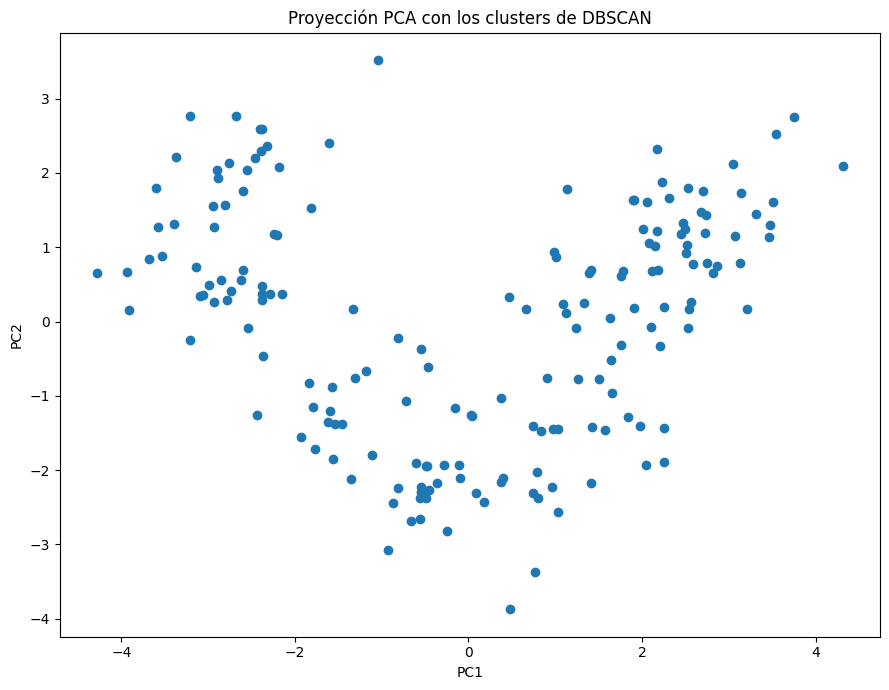

In [21]:
# COMPLETAR
plt.figure(figsize=(9, 7))
plt.scatter(pc1[clusters_dbs == -1], pc2[clusters_dbs == -1])
plt.scatter(pc1[clusters_dbs != -1], pc2[clusters_dbs != -1], c=clusters_dbs[clusters_dbs != -1])
plt.title("Proyección PCA con los clusters de DBSCAN")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Ejercicio 23

Pregunta:

1. ¿DBSCAN encuentra una estructura clara en este dataset?
2. ¿Aparecen puntos marcados como ruido?
3. ¿Qué diferencia conceptual hay entre k-medias y DBSCAN?

**Respuesta.**

1. No. En lugar de separar las 3 variedades de vino, ha metido casi todos los datos en una única masa.
2. Si, marca todos los puntos como ruido.
3. K-medias: le obligamos a buscar un número fijo de grupos. Divide todo el espacio con fronteras rígidas y asigna absolutamente todos los puntos a un grupo, sin importar si hay muestras que son anomalías o están lejísimos.
   DBSCAN: busca regiones donde los puntos estén muy apiñados (eps y min_samples). Si el espacio se vuelve soso o vacío, deja de agrupar, lo que le permite descubrir grupos con formas irregulares y aislar de forma nativa los datos atípicos como ruido.


# Sensibilidad de DBSCAN a eps

## Ejercicio 24

Prueba varios valores de `eps`, por ejemplo:

$$
eps \in \{0.8,1.0,1.2,1.5,2.0,2.5\}
$$

Para cada valor calcula:

- número de clusters,
- número de puntos de ruido.

In [22]:
# COMPLETAR
eps_vals = [0.8, 1.0, 1.2, 1.5, 2.0, 2.5]
res = []

for eps in eps_vals:
    dbs = DBSCAN(eps=eps, min_samples=5)
    etiquetas = dbs.fit_predict(X_scaled)

    n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    n_ruido = list(etiquetas).count(-1)
    
    res.append({
        "num clusters": n_clusters,
        "num ruido": n_ruido
    })

res = pd.DataFrame(res)

## Ejercicio 25

Representa:

- número de clusters frente a `eps`,
- número de puntos de ruido frente a `eps`.

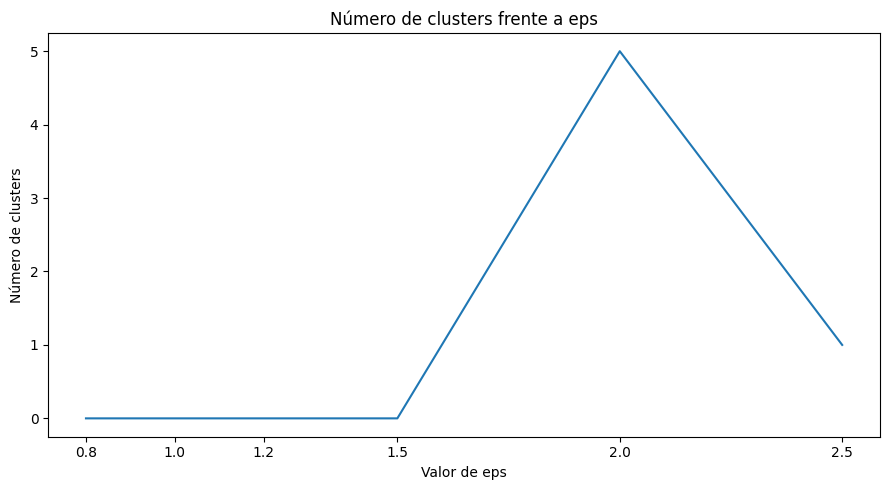

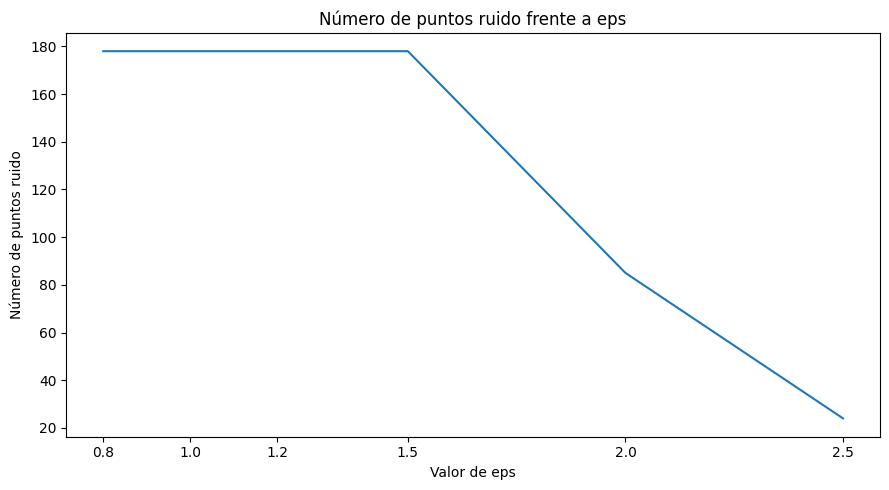

In [23]:
# COMPLETAR
plt.figure(figsize=(9, 5))
plt.plot(eps_vals, res["num clusters"])
plt.title("Número de clusters frente a eps")
plt.xlabel("Valor de eps")
plt.ylabel("Número de clusters")
plt.xticks(eps_vals, labels=[str(c) for c in eps_vals]) 
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(eps_vals, res["num ruido"])
plt.title("Número de puntos ruido frente a eps")
plt.xlabel("Valor de eps")
plt.ylabel("Número de puntos ruido")
plt.xticks(eps_vals, labels=[str(c) for c in eps_vals]) 
plt.tight_layout()
plt.show()

## Ejercicio 26

Pregunta:

1. ¿Qué ocurre cuando `eps` es muy pequeño?
2. ¿Qué ocurre cuando `eps` es muy grande?
3. ¿Por qué DBSCAN es sensible a la escala de los datos?

**Respuesta.**

1. El radio de búsqueda es tan estrecho que los puntos no alcanzan a conectarse entre sí, marcando todo como ruido.
2. El radio se vuelve tan grande que un solo punto se conecta con casi cualquier otro. Fusiona todos los datos en un único gran cluster.
3. Porque define la cercanía mediante una distancia en un radio eps. Si los datos no están en la misma escala, las variables con números grandes deforman el espacio; un valor de eps que funcione bien para la variable grande será gigantesco para la pequeña.

# PCA como reducción de dimensionalidad

## Ejercicio 27

Aplica PCA conservando todas las componentes.

Representa la varianza explicada acumulada frente al número de componentes.

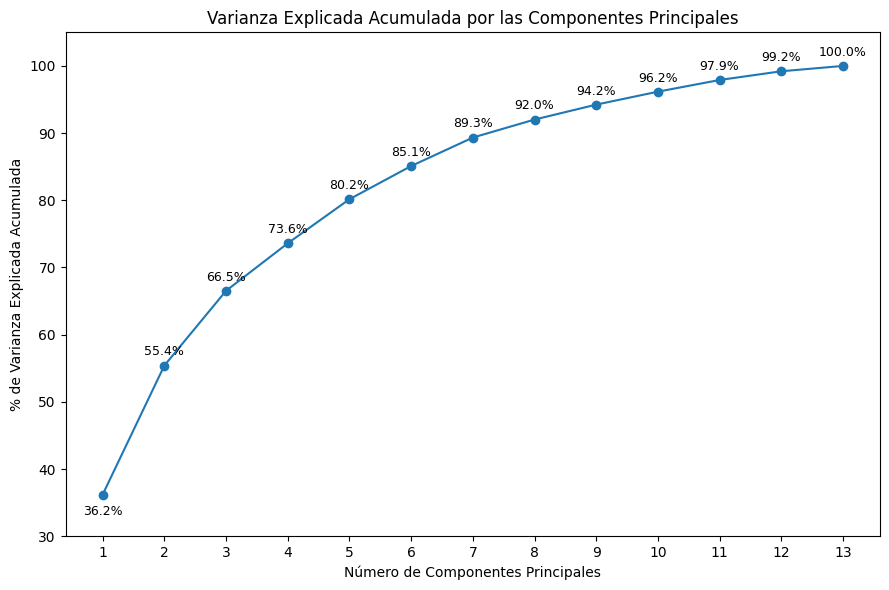

In [24]:
# COMPLETAR
pca2 = PCA(random_state=CODIGO_ESTUDIANTE)
pca2.fit(X_scaled)

varianza_acumulada = np.cumsum(pca2.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")
for i, v in enumerate(varianza_acumulada):
    plt.text(i + 1, v - 3 if i == 0 else v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.title("Varianza Explicada Acumulada por las Componentes Principales")
plt.xlabel("Número de Componentes Principales")
plt.ylabel("% de Varianza Explicada Acumulada")
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.ylim(30, 105)
plt.tight_layout()
plt.show()

## Ejercicio 28

Pregunta:

1. ¿Cuántas componentes se necesitan aproximadamente para explicar al menos el 80% de la varianza?
2. ¿Y para explicar al menos el 90%?
3. ¿Qué relación tiene esto con la reducción de dimensionalidad?

**Respuesta.**

1. 5
2. 8
3. Podemos comprimir el dataset de las 13 dimensiones originales a solo 5 o 8, simplificando los datos y acelerando cualquier algoritmo, sacrificando un bajo porcentaje de información.

# Clustering después de PCA

## Ejercicio 29

Aplica k-medias con `k=3` usando solo las primeras dos componentes principales.

Compara sus resultados con k-medias aplicado a todas las variables escaladas.

Calcula:

- silhouette score,
- ARI respecto a las etiquetas ocultas.

In [25]:
# COMPLETAR
km2 = KMeans(n_clusters=3, n_init=10, random_state=CODIGO_ESTUDIANTE)
clusters_pca = km2.fit_predict(X_pca)

sil_modelo_pca = silhouette_score(X_pca, clusters_pca)
sil_modelo_completo = silhouette_score(X_scaled, clusters_k3)

ari_modelo_pca = adjusted_rand_score(y_oculta, clusters_pca)
ari_modelo_completo = adjusted_rand_score(y_oculta, clusters_k3)

df_comparativa = pd.DataFrame({
    "Métrica": ["silhouette score", "ARI (vs y_oculta)"],
    "2 Componentes (PCA)": [sil_modelo_pca, ari_modelo_pca],
    "13 Variables (Completo)": [sil_modelo_completo, ari_modelo_completo]
})

df_comparativa.to_string

<bound method DataFrame.to_string of              Métrica  2 Componentes (PCA)  13 Variables (Completo)
0   silhouette score             0.561051                 0.284859
1  ARI (vs y_oculta)             0.895058                 0.897495>

## Ejercicio 30

Pregunta:

1. ¿Se pierde información al usar solo dos componentes?
2. ¿El clustering en 2D funciona mejor o peor que con todas las variables?
3. ¿Por qué puede ser útil hacer PCA antes de clustering?

**Respuesta.**

1. Si, perdemos un 44% de información, pero no afecta apenas al resultado final.
2. Tienen un ARI casi igual pero el score se duplica de forma falsa, ya que al pasar a solo 2D, los puntos están más compactos.
3. Para reducir dimensiones, eliminar ruido y verlo de forma visual.

# Comparación final

## Ejercicio 31

Construye una tabla resumen comparando al menos:

- k-medias con `k=3` sobre todas las variables,
- k-medias con el mejor `k` según silhouette,
- DBSCAN con el valor de `eps` elegido,
- k-medias con `k=3` sobre las dos primeras componentes PCA.

La tabla debe incluir, cuando tenga sentido:

- número de clusters,
- silhouette score,
- ARI,
- NMI,
- número de puntos de ruido.

In [26]:
# COMPLETAR
df_resumen = pd.DataFrame({
    "Configuración / Modelo": [
        "K-medias (k=3, Variables Completas)",
        "K-medias (Mejor k=3 según Silhouette)",
        "DBSCAN (eps=1.5, min_samples=5)",
        "K-medias (k=3, 2 Componentes PCA)"
    ],
    "Nº Clusters": [3, 3, 1, 3],
    "Silhouette Score": [
        silhouette_score(X_scaled, clusters_k3),
        silhouette_score(X_scaled, clusters_k3),
        0.0,  # No definido/No tiene sentido con 1 solo cluster
        silhouette_score(X_pca, clusters_pca)
    ],
    "ARI": [
        adjusted_rand_score(y_oculta, clusters_k3),
        adjusted_rand_score(y_oculta, clusters_k3),
        adjusted_rand_score(y_oculta, clusters_dbs),
        adjusted_rand_score(y_oculta, clusters_pca)
    ],
    "NMI": [
        normalized_mutual_info_score(y_oculta, clusters_k3),
        normalized_mutual_info_score(y_oculta, clusters_k3),
        normalized_mutual_info_score(y_oculta, clusters_dbs),
        normalized_mutual_info_score(y_oculta, clusters_pca)
    ],
    "Puntos Ruido": [0, 0, 178, 0]
})

df_resumen

,Configuración / Modelo,Nº Clusters,Silhouette Score,ARI,NMI,Puntos Ruido
0,"K-medias (k=3, Variables Completas)",3,0.284859,0.897495,0.875894,0
1,K-medias (Mejor k=3 según Silhouette),3,0.284859,0.897495,0.875894,0
2,"DBSCAN (eps=1.5, min_samples=5)",1,0.000000,0.000000,0.000000,178
3,"K-medias (k=3, 2 Componentes PCA)",3,0.561051,0.895058,0.882065,0


## Ejercicio 32

Pregunta:

1. ¿Qué método parece descubrir mejor la estructura de los datos?
2. ¿Qué método produce una visualización más clara?
3. ¿Qué diferencia hay entre evaluar clustering internamente y compararlo con etiquetas ocultas?

**Respuesta.**

1. K-medias con k=3 por sus métricas externas (ARI y NMI cercanas a 0.90).
2. K-medias aplicado sobre las dos primeras componentes de PCA. Al proyectar los datos en el plano 2D, las fronteras de K-medias se vuelven nítidas y los grupos se ven compactos y perfectamente separados visualmente.
3. La interna (Silhouette) solo mide la geometría de los grupos (si están juntos o separados) sin saber nada de la realidad, mientras que la externa (ARI/NMI) comprueba si esos grupos coinciden con la verdad del problema.

# Ejercicio final de reflexión

Responde brevemente a las siguientes preguntas.

1. ¿Qué diferencia hay entre aprendizaje supervisado y no supervisado?
2. ¿Qué optimiza k-medias?
3. ¿Qué mide el silhouette score?
4. ¿Qué ventajas tiene DBSCAN frente a k-medias?
5. ¿Qué inconvenientes tiene DBSCAN?
6. ¿Por qué PCA requiere escalar los datos?
7. ¿Por qué PCA puede ser útil para visualizar datos?
8. ¿Por qué las etiquetas ocultas no deben usarse para entrenar modelos no supervisados?

**Respuesta.**

1. El supervisado usa etiquetas reales para aprender a predecir, mientras que el no supervisado busca patrones ocultos en datos sin etiquetar.
2. Optimiza la inercia, minimiza la suma de las distancias euclidianas al cuadrado entre cada punto y el centroide de su cluster.
3. Mide la calidad del agrupamiento evaluando qué tan cerca está un punto de su propio cluster (cohesión) frente a los demás (separación).
4. Descubre clusters de formas irregulares de manera automática sin pedir el número de grupos y aísla el ruido y anomalías.
5. Es muy sensible a los hiperparámetros (eps y min_samples) y falla detectando clusters en datasets que tienen densidades muy variables.
6. Porque se basa en maximizar la varianza; si no se escalan, las variables con magnitudes grandes dominan artificialmente sobre las pequeñas.
7. Porque reduce las dimensiones complejas (como 13 variables) a solo 2 o 3 componentes, permitiendo proyectar los datos en un gráfico plano.
8. Porque rompería la naturaleza del aprendizaje no supervisado, cuya meta es descubrir la estructura de los datos sin guías externas.

# Entrega

La entrega debe incluir:

- el notebook completado,
- todas las gráficas,
- las tablas de resultados,
- las respuestas razonadas,
- y la interpretación de resultados.

No basta con ejecutar código: las respuestas deben explicar qué significan los resultados obtenidos.

# Comentario sobre el código de estudiante

Todos los estudiantes trabajarán con el mismo dataset completo, pero usarán distintos valores de `random_state` derivados de su código de estudiante.

Esto hace que:

- las inicializaciones de k-medias puedan cambiar ligeramente,
- algunas representaciones sean ligeramente distintas,
- los resultados numéricos no sean exactamente iguales,
- pero todos trabajen sobre el mismo problema y puedan compararse resultados.

Esta estrategia facilita:

- la corrección,
- la comparación en clase,
- y evita que algunos estudiantes reciban subconjuntos demasiado fáciles o difíciles.